In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Connect to PostgreSQL
engine = create_engine('postgresql://localhost/olist_ecommerce')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Connected successfully!")

Connected successfully!


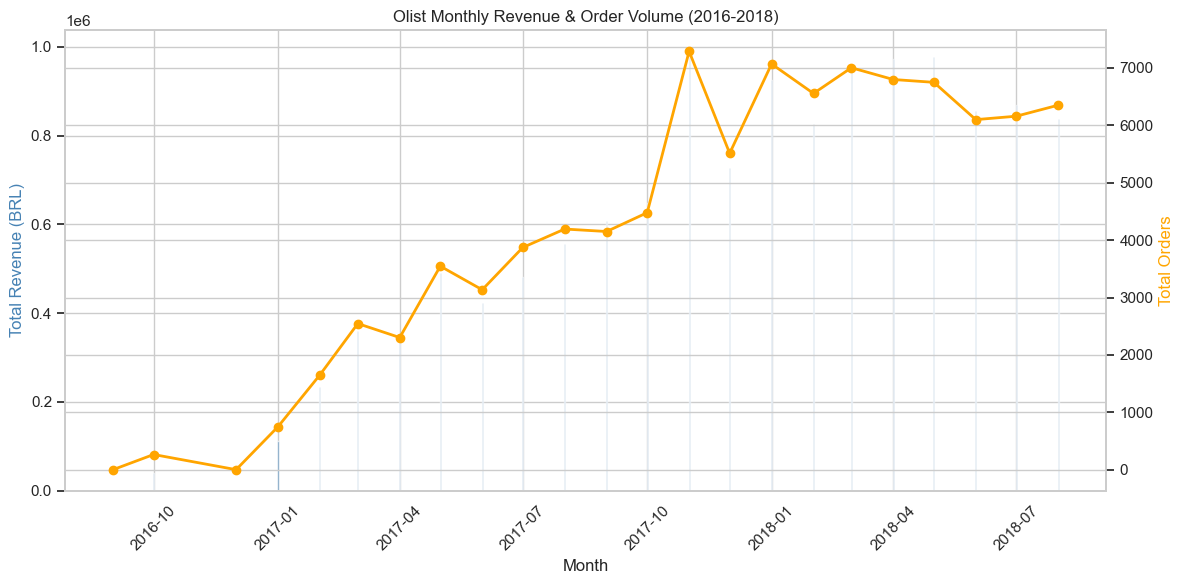

In [3]:
# Monthly revenue query
monthly_revenue = pd.read_sql("""
    SELECT 
        DATE_TRUNC('month', order_purchase_timestamp::timestamp) AS month,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price)::numeric, 2) AS total_revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1;
""", engine)

# Plot
fig, ax1 = plt.subplots()

# Revenue bars
ax1.bar(monthly_revenue['month'], monthly_revenue['total_revenue'], 
        color='steelblue', alpha=0.7, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Orders line on second axis
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['month'], monthly_revenue['total_orders'], 
         color='orange', linewidth=2, marker='o', label='Orders')
ax2.set_ylabel('Total Orders', color='orange')

plt.title('Olist Monthly Revenue & Order Volume (2016-2018)')
fig.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

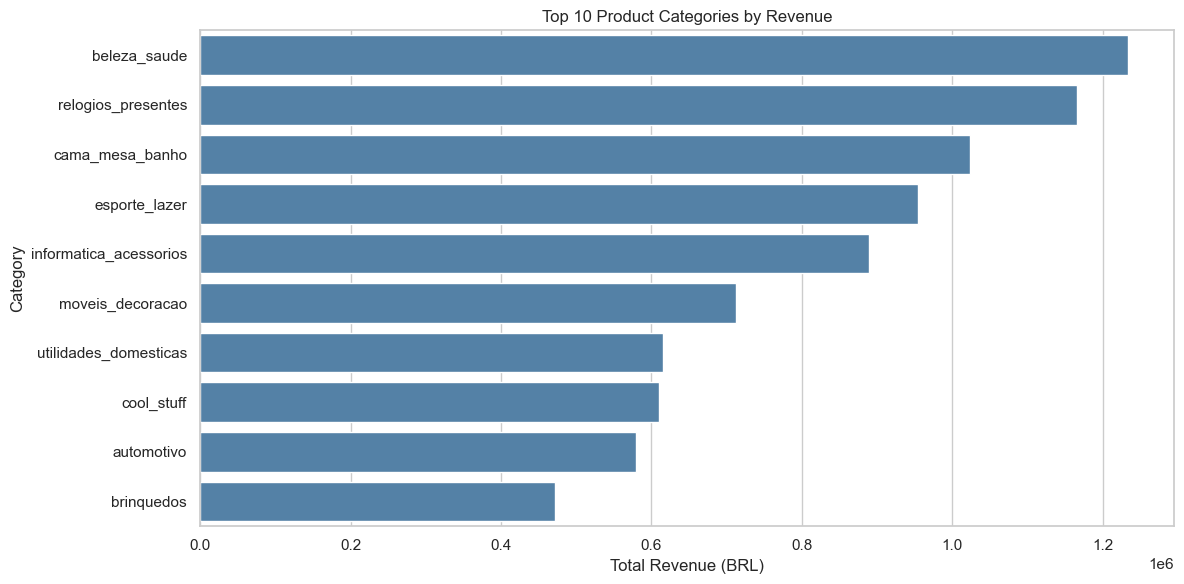

In [ ]:
# Revenue by product category
category_revenue = pd.read_sql("""
    SELECT 
        p.product_category_name AS category,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price)::numeric, 2) AS total_revenue,
        ROUND(AVG(oi.price)::numeric, 2) AS avg_order_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY total_revenue DESC
    LIMIT 10;
""", engine)

# Plot
plt.figure()
sns.barplot(data=category_revenue, x='total_revenue', y='category', color='steelblue')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150, bbox_inches='tight')
plt.show() 

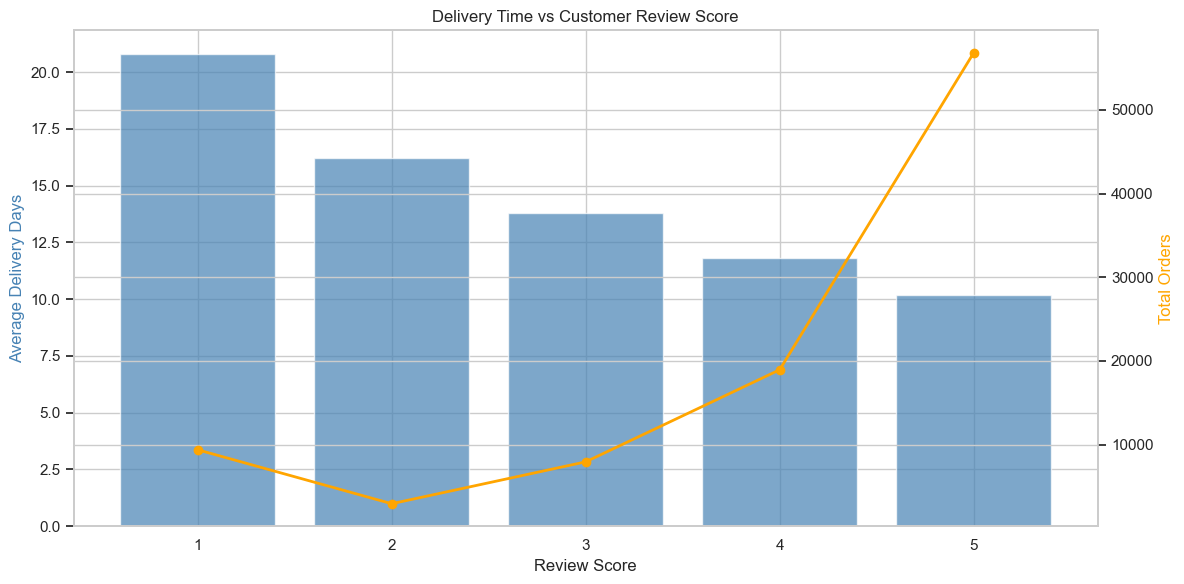

In [8]:
# Delivery time vs review score
delivery_reviews = pd.read_sql("""
    SELECT 
        r.review_score,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(AVG(
            DATE_PART('day', o.order_delivered_customer_date::timestamp - 
            o.order_purchase_timestamp::timestamp)
        )::numeric, 1) AS avg_delivery_days
    FROM orders o
    JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    ORDER BY 1;
""", engine)

# Plot
fig, ax1 = plt.subplots()

# Delivery days bars
ax1.bar(delivery_reviews['review_score'], delivery_reviews['avg_delivery_days'],
        color='steelblue', alpha=0.7, label='Avg Delivery Days')
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Average Delivery Days', color='steelblue')

# Order count line
ax2 = ax1.twinx()
ax2.plot(delivery_reviews['review_score'], delivery_reviews['total_orders'],
         color='orange', linewidth=2, marker='o', label='Total Orders')
ax2.set_ylabel('Total Orders', color='orange')

plt.title('Delivery Time vs Customer Review Score')
fig.tight_layout()
plt.savefig('delivery_reviews.png', dpi=150, bbox_inches='tight')
plt.show()